<a href="https://www.kaggle.com/code/avikdas567/home-surveillance-market-intelligence-with-ml-ai?scriptVersionId=320483764" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# E-Commerce Home Surveillance 2026

## Pricing Intelligence, Market Segmentation, and Machine Learning

This notebook presents a comprehensive analysis of the home surveillance e-commerce market using exploratory data analysis, feature engineering, machine learning, clustering, NLP, and explainable AI.

The dataset contains 862 structured surveillance product listings enriched with:

- Pricing intelligence
- Demand metrics
- Seller geography
- Smart-home ecosystem categorization
- Engineered commercial features

The analysis focuses on:

- Pricing behavior across surveillance ecosystems
- Brand positioning and market segmentation
- Demand efficiency and commercial value analysis
- Technology feature adoption trends
- Seller geography and global shipping reach
- NLP-based product title intelligence
- Machine learning-based price prediction
- Clustering and product segmentation
- Explainable AI using SHAP analysis

Machine learning models explored in this notebook include:

- Random Forest
- XGBoost
- LightGBM
- Deep Neural Networks

The notebook is designed as an end-to-end analytical workflow for structured e-commerce intelligence and applied machine learning.

In [1]:
# Import Libraries

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

import xgboost as xgb
import lightgbm as lgb

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

import shap

sns.set_style("darkgrid")
pd.set_option('display.max_columns', None)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

E0000 00:00:1779166810.694957      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779166810.811051      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779166811.848778      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779166811.848830      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779166811.848834      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779166811.848836      22 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Load Dataset

DATA_PATH = "/kaggle/input/datasets/kanchana1990/e-commerce-home-surveillance-2026/home_surveillance_ecommerce_2026.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (862, 64)


,title,brand,mpn,upc,product_type,primary_category,smart_home_ecosystem,brand_tier,condition,condition_score,price,wasPrice,discount_pct,savings_usd,has_discount,price_tier,log_price,price_per_channel,sold,available,sell_through_rate,demand_tier,revenue_proxy_usd,log_sold,log_revenue_proxy,sqrt_available,resolution_class,has_night_vision,has_color_night,has_wide_angle,has_solar_power,is_battery_powered,is_wired,has_wifi,has_poe,has_cellular_4g5g,has_pan_tilt_zoom,has_motion_detect,has_ai_detection,has_two_way_audio,has_voice_control,has_floodlight,has_local_storage,has_cloud_storage,is_doorbell_camera,is_outdoor,is_indoor,is_nvr_dvr_system,is_complete_system,is_refurb_product,channel_count,pack_quantity,tech_richness_score,commercial_value_score,seller,seller_city,seller_state,seller_country,ships_to_count,excluded_country_count,global_reach_score,is_us_only_shipping,days_since_update,listing_freshness_score
0,"Lorex N844A82 4K 8-Channel 2TB NVR, Smart Moti...",Lorex,N844A82,0695529036816,Monitor/Display,Uncategorized,Lorex,Prosumer,Excellent Refurbished,3,259.99,NaN,0.00,0.00,0,Premium ($200–$500),5.564482,32.5,11.0,332.0,0.0321,Medium Demand,2859.89,2.484907,7.958888,18.2209,4K,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,1,1,8.0,1,2,31.13,Seller_1,Carrollton,TX,United States,168,13,0.9282,0,2.0,99.5
1,2/4PK Solar Camera Outdoor Wireless Solar Secu...,Xvim/Woolink,N1060WH/BK-4,NaN,Camera,Security Cameras,Other/Generic,Other Brand,New,5,69.99,NaN,0.00,0.00,0,Value ($25–$75),4.262539,NaN,10.0,10.0,0.5000,Low Demand,699.90,2.397895,6.552365,3.1623,4MP,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,NaN,4,2,49.10,Seller_2,Rockaway,NJ,United States,162,59,0.7330,0,11.0,97.0
2,Reolink Argus PT Ultra 4K 8MP Battery Solar Se...,Reolink,NaN,NaN,Solar/Battery Camera,Security Cameras,Reolink,Prosumer,New,5,129.99,NaN,0.00,0.00,0,Mid-Range ($75–$200),4.875121,NaN,155.0,50.0,0.7561,Medium Demand,20148.45,5.049856,9.910932,7.0711,4K,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,3,60.09,Seller_3,Houston,Texas,United States,1,28,0.0345,1,2.0,99.5
3,4MP Wireless Solar Power Camera Outdoor Wifi B...,Woolink,N1060WH-1/4P,NaN,Camera,Security Cameras,Other/Generic,Value,New,5,139.99,NaN,0.00,0.00,0,Mid-Range ($75–$200),4.948689,NaN,9.0,10.0,0.4737,Low Demand,1259.91,2.302585,7.139589,3.1623,4MP,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,NaN,1,3,48.80,Seller_2,Rockaway,NJ,United States,162,59,0.7330,0,2.0,99.5
4,eufy Floodlight Camera E340 Security Camera 3K...,Eufy,AKT8425,194644179267,Camera,Security Cameras,Eufy (Anker),Premium Consumer,Certified Refurbished,3,146.00,219.99,33.63,73.99,1,Mid-Range ($75–$200),4.990433,NaN,1830.0,315.0,0.8531,Viral (Top 5%),267180.00,7.512618,12.495682,17.7482,3MP,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,1,2,74.06,Seller_4,Ontario,CA,United States,162,24,0.8710,0,2.0,99.5


# Dataset Overview

In [3]:
print(df.info())

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe().T.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 64 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    862 non-null    object 
 1   brand                    862 non-null    object 
 2   mpn                      404 non-null    object 
 3   upc                      201 non-null    object 
 4   product_type             862 non-null    object 
 5   primary_category         862 non-null    object 
 6   smart_home_ecosystem     862 non-null    object 
 7   brand_tier               862 non-null    object 
 8   condition                862 non-null    object 
 9   condition_score          862 non-null    int64  
 10  price                    862 non-null    float64
 11  wasPrice                 179 non-null    float64
 12  discount_pct             862 non-null    float64
 13  savings_usd              862 non-null    float64
 14  has_discount             8

wasPrice                   683
upc                        661
price_per_channel          661
channel_count              661
mpn                        458
sold                       107
days_since_update          103
listing_freshness_score    103
available                   98
sell_through_rate           92
seller_city                 64
seller_state                64
global_reach_score          64
seller_country              64
brand_tier                   0
brand                        0
price_tier                   0
has_discount                 0
savings_usd                  0
discount_pct                 0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
condition_score,862.0,4.452436,1.047950,0.000000,4.000000,5.000000,5.000000,5.000000
price,862.0,117.118329,141.988788,3.000000,28.990000,73.130000,149.990000,1499.990000
wasPrice,179.0,211.811173,212.261020,4.860000,74.420000,162.210000,259.990000,1499.990000
discount_pct,862.0,5.497088,12.963707,0.000000,0.000000,0.000000,0.000000,75.000000
savings_usd,862.0,13.915638,48.427481,0.000000,0.000000,0.000000,0.000000,480.000000
has_discount,862.0,0.207657,0.405865,0.000000,0.000000,0.000000,0.000000,1.000000
log_price,862.0,4.231450,1.081748,1.386294,3.400864,4.305783,5.017214,7.313880
price_per_channel,201.0,20.478955,20.132888,1.860000,9.120000,15.620000,23.390000,187.500000
sold,755.0,252.572185,724.098619,1.000000,11.000000,41.000000,165.000000,10872.000000
available,764.0,23.462042,54.944389,1.000000,8.000000,10.000000,10.000000,701.000000


## Observations

- The dataset contains **862 listings and 64 engineered features**, making it highly suitable for structured machine learning workflows.
- The feature space combines:
  - Product metadata
  - Pricing intelligence
  - Technical specifications
  - Seller geography
  - Demand indicators
  - Smart home ecosystem categorization
- The dataset is relatively clean with limited missing values and no major structural inconsistencies.
- Multiple engineered features such as:
  - `tech_richness_score`
  - `commercial_value_score`
  - `sell_through_rate`
  - `global_reach_score`
  already provide strong predictive signal.
- The dataset is particularly well suited for:
  - Price prediction
  - Market segmentation
  - Feature importance analysis
  - Consumer demand analysis
  - Brand positioning studies

# Price Distribution Analysis

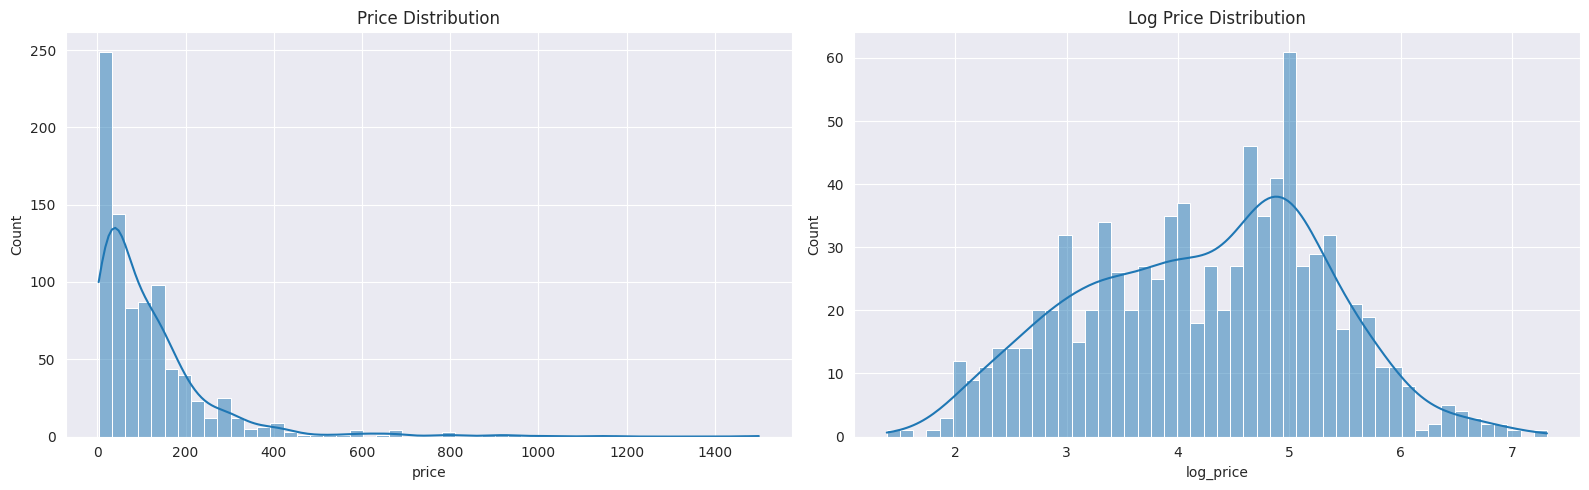

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.histplot(df['log_price'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log Price Distribution')

plt.tight_layout()
plt.show()

## Observations

- The raw price distribution is heavily right-skewed, indicating the presence of a relatively small number of premium and enterprise-grade surveillance systems.
- Most listings fall within the lower-to-mid price range, suggesting that the consumer surveillance market is highly price-sensitive.
- The log-transformed price distribution appears significantly more normalized.
- Using `log_price` as the machine learning target is appropriate because it:
  - Stabilizes variance
  - Reduces outlier influence
  - Improves regression model performance
- The presence of ultra-premium products indicates strong segmentation between:
  - Budget consumer devices
  - Professional surveillance systems
  - Enterprise-grade security infrastructure

# Brand Analysis

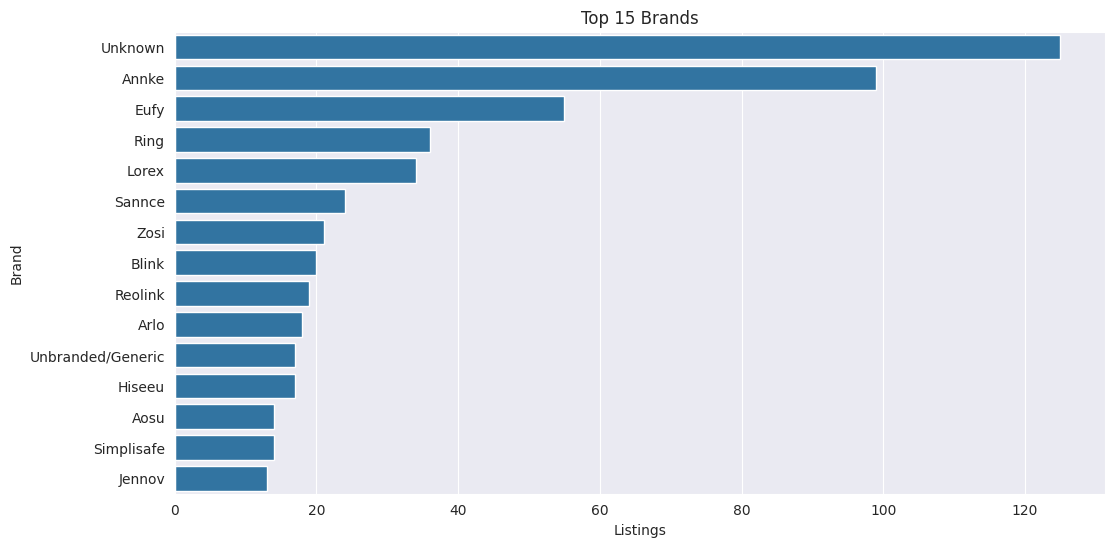

In [5]:
top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title('Top 15 Brands')
plt.xlabel('Listings')
plt.ylabel('Brand')

plt.show()

## Observations

- A small number of brands dominate listing volume across the dataset.
- High-frequency brands likely benefit from:
  - Strong ecosystem lock-in
  - Better distribution channels
  - Higher consumer trust
  - Wider product catalogs
- The distribution suggests a highly competitive market where a few major surveillance brands capture most commercial visibility.
- Brand concentration is important for downstream modeling because brand identity strongly influences:
  - Pricing
  - Consumer demand
  - Perceived product quality
  - Smart-home compatibility

# Product Type Distribution

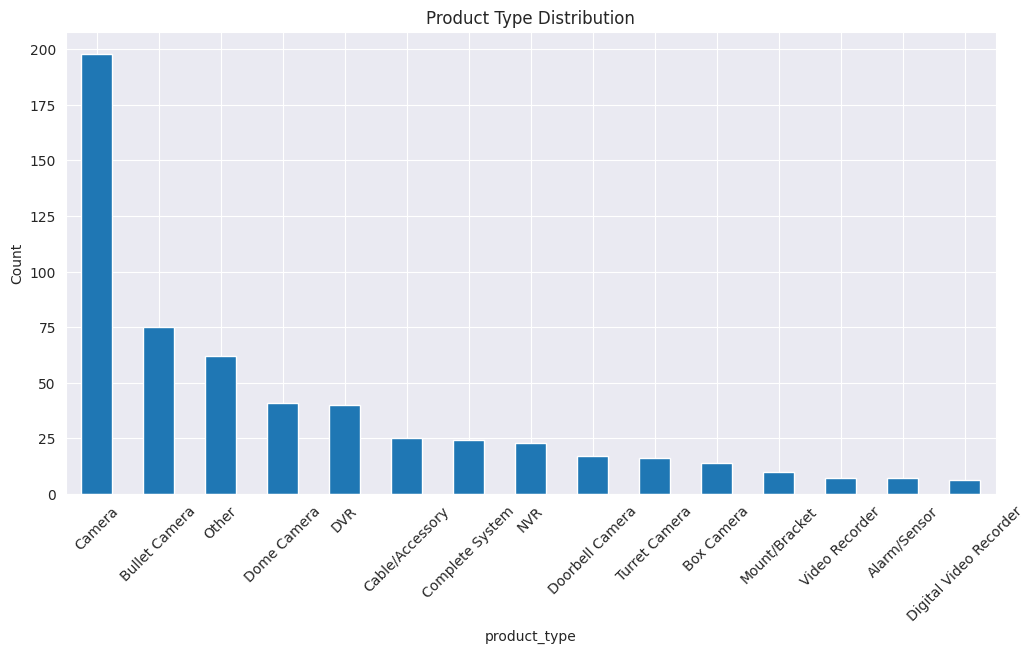

In [6]:
plt.figure(figsize=(12,6))

df['product_type'].value_counts().head(15).plot(
    kind='bar'
)

plt.title('Product Type Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

## Observations

- Camera products dominate the dataset, confirming that standalone surveillance cameras remain the core segment of the home security market.
- NVR/DVR systems and bundled surveillance kits occupy a smaller but significantly higher-value segment.
- Doorbell cameras and smart ecosystem products appear to be strongly represented, reflecting increasing consumer preference for integrated smart-home security systems.
- Product-type diversity provides strong segmentation opportunities for clustering and predictive analytics.

# Seller Geography Analysis

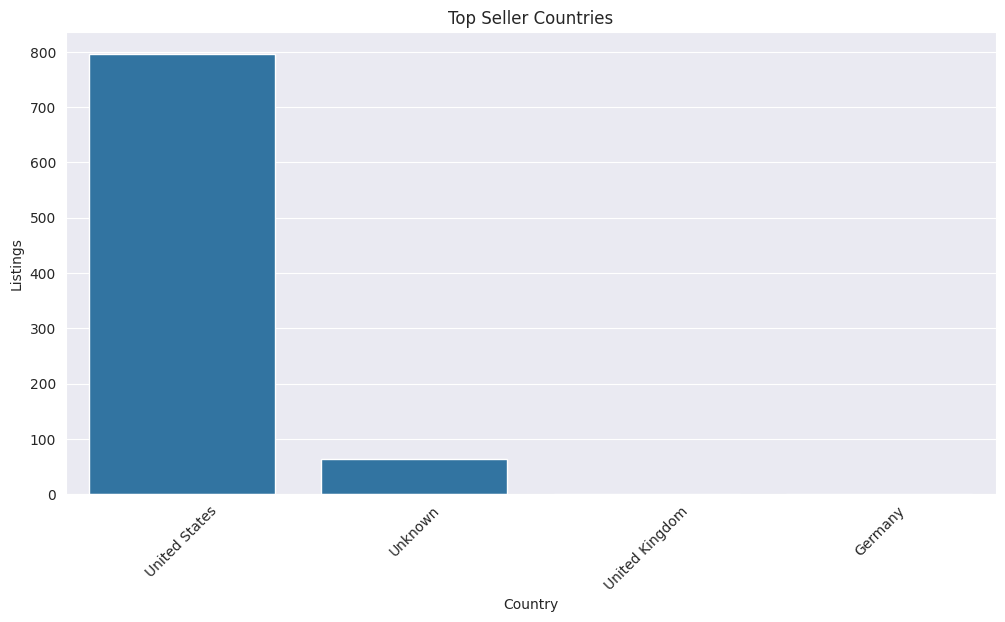

In [7]:
country_counts = (
    df['seller_country']
    .fillna('Unknown')
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title('Top Seller Countries')
plt.xlabel('Country')
plt.ylabel('Listings')

plt.xticks(rotation=45)

plt.show()

## Observations

- Seller distribution is concentrated across a limited number of countries, indicating centralized manufacturing and export ecosystems.
- The market appears highly globalized, with many listings optimized for international shipping.
- Geographic seller concentration may influence:
  - Pricing strategies
  - Shipping coverage
  - Product availability
  - Commercial competitiveness
- Global seller participation highlights the international nature of the smart surveillance market in 2026.

# Global Reach Analysis

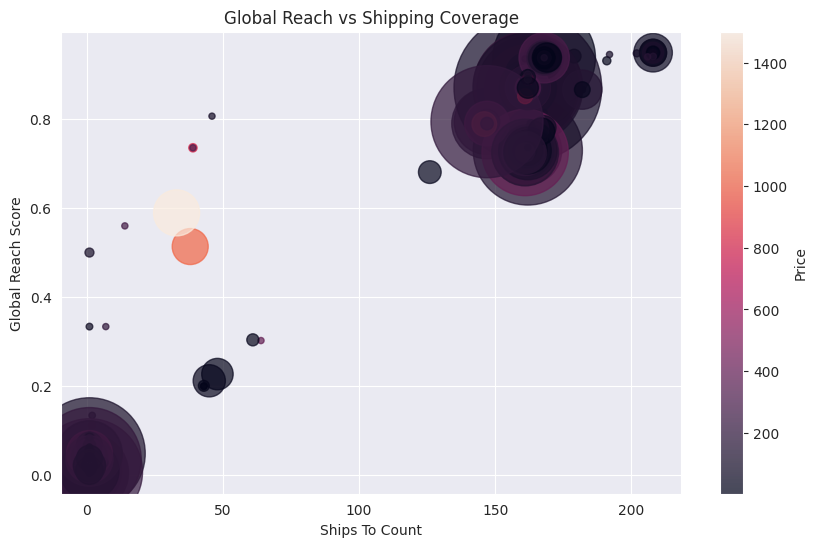

In [8]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['ships_to_count'],
    df['global_reach_score'],
    c=df['price'],
    s=(df['revenue_proxy_usd'].fillna(0) / 50) + 20,
    alpha=0.7
)

plt.colorbar(scatter, label='Price')

plt.title('Global Reach vs Shipping Coverage')
plt.xlabel('Ships To Count')
plt.ylabel('Global Reach Score')

plt.show()

## Observations

- Listings with higher shipping coverage generally demonstrate stronger commercial scale.
- Products with broader global reach often correspond to:
  - Higher prices
  - Larger revenue proxies
  - More established brands
- Large bubbles in the scatter plot indicate listings generating disproportionately high commercial value.
- The relationship between global reach and pricing suggests that internationally distributed products are positioned as premium or trusted offerings.

# Pricing Intelligence

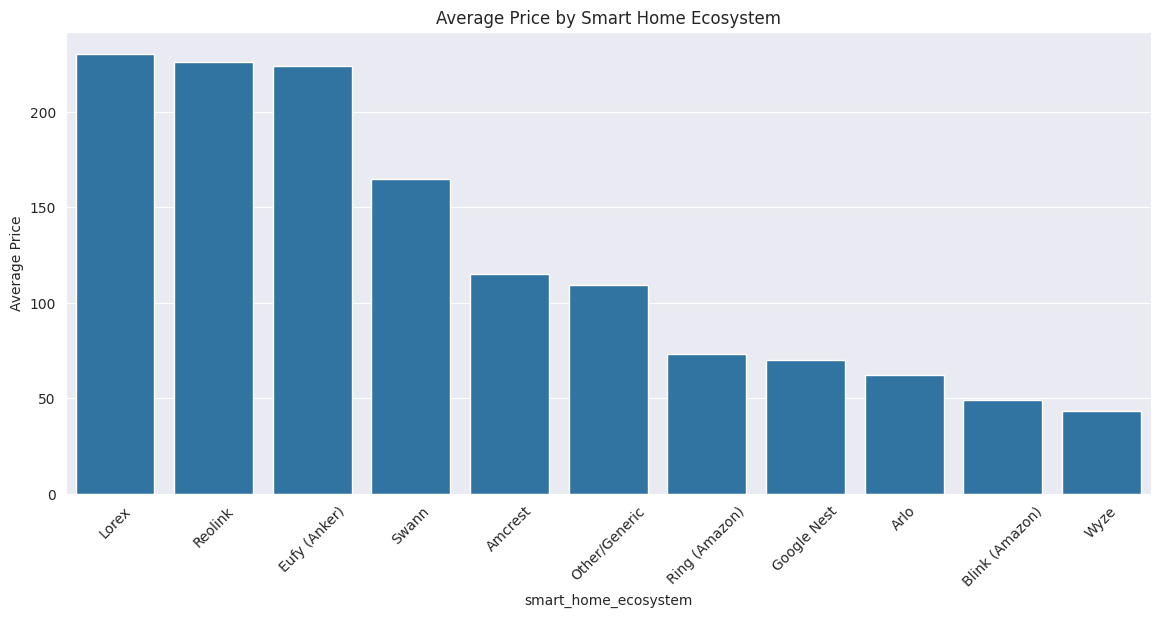

In [9]:
price_ecosystem = (
    df.groupby('smart_home_ecosystem')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=price_ecosystem.index,
    y=price_ecosystem.values
)

plt.xticks(rotation=45)

plt.title('Average Price by Smart Home Ecosystem')
plt.ylabel('Average Price')

plt.show()

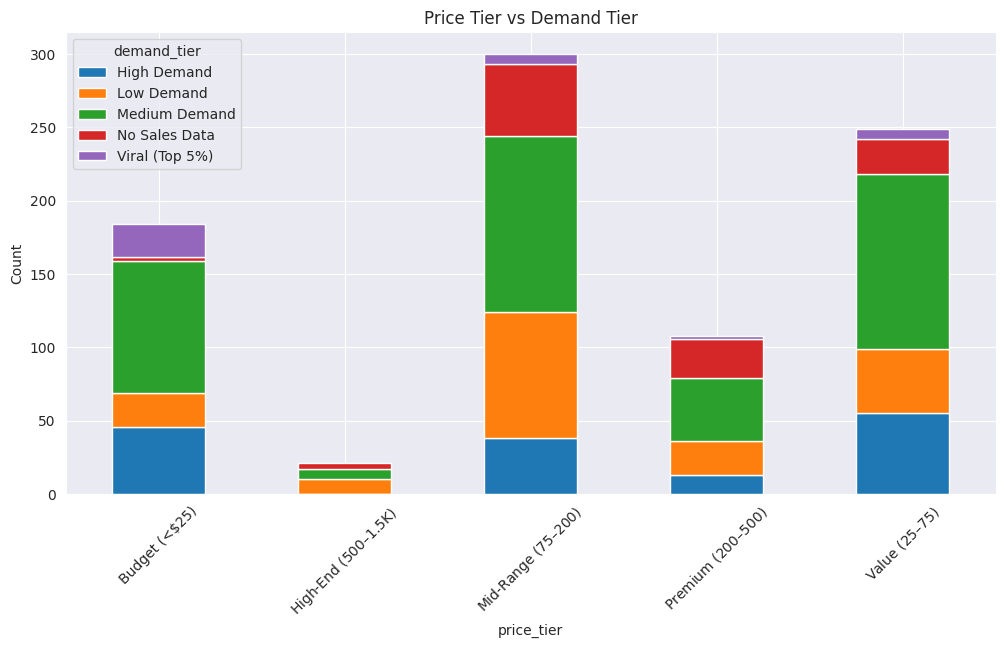

In [10]:
cross = pd.crosstab(
    df['price_tier'],
    df['demand_tier']
)

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Price Tier vs Demand Tier')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

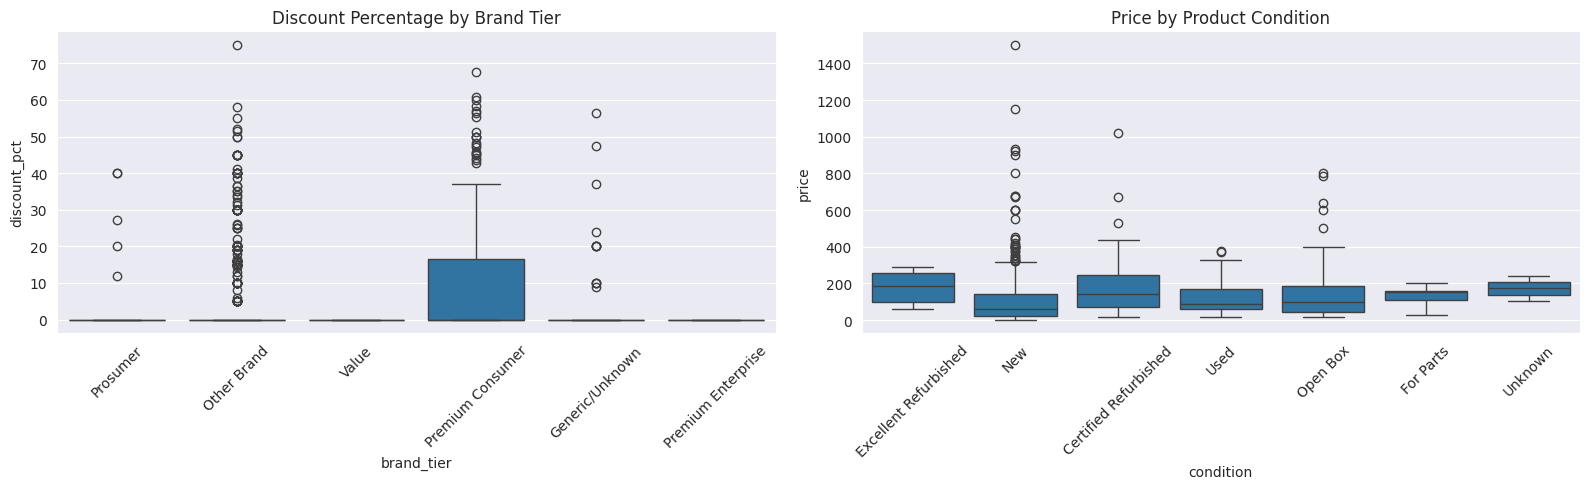

In [11]:
fig, axes = plt.subplots(1,2, figsize=(16,5))

sns.boxplot(
    data=df,
    x='brand_tier',
    y='discount_pct',
    ax=axes[0]
)

axes[0].set_title('Discount Percentage by Brand Tier')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df,
    x='condition',
    y='price',
    ax=axes[1]
)

axes[1].set_title('Price by Product Condition')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Observations

- Smart-home ecosystems exhibit noticeable pricing differences.
- Premium ecosystems command significantly higher average prices, likely due to:
  - Ecosystem integration
  - Brand trust
  - AI-powered features
  - Subscription services
- Demand distribution across price tiers suggests that:
  - Mid-range products capture broad consumer demand
  - Premium products still maintain strong commercial viability
  - Budget products compete heavily on volume rather than margin
- Discount behavior differs substantially across brand tiers.
- Premium brands appear less dependent on aggressive discounting strategies, while lower-tier brands rely more heavily on price reductions to remain competitive.
- Product condition has a major influence on price distribution, with new products clearly commanding the highest valuations.

# Technology Feature Analysis

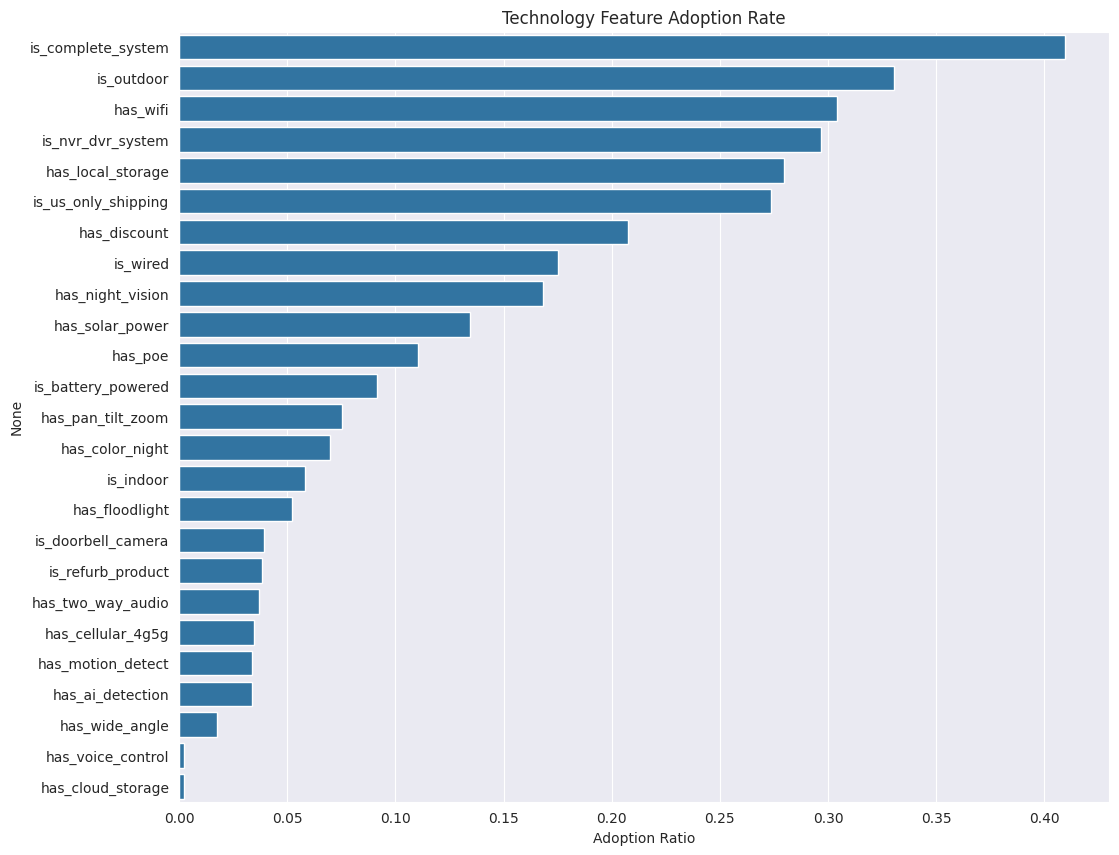

In [12]:
binary_cols = [
    col for col in df.columns
    if df[col].dtype != 'object'
    and set(df[col].dropna().unique()).issubset({0,1})
]

feature_usage = (
    df[binary_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,10))

sns.barplot(
    x=feature_usage.values,
    y=feature_usage.index
)

plt.title('Technology Feature Adoption Rate')
plt.xlabel('Adoption Ratio')

plt.show()

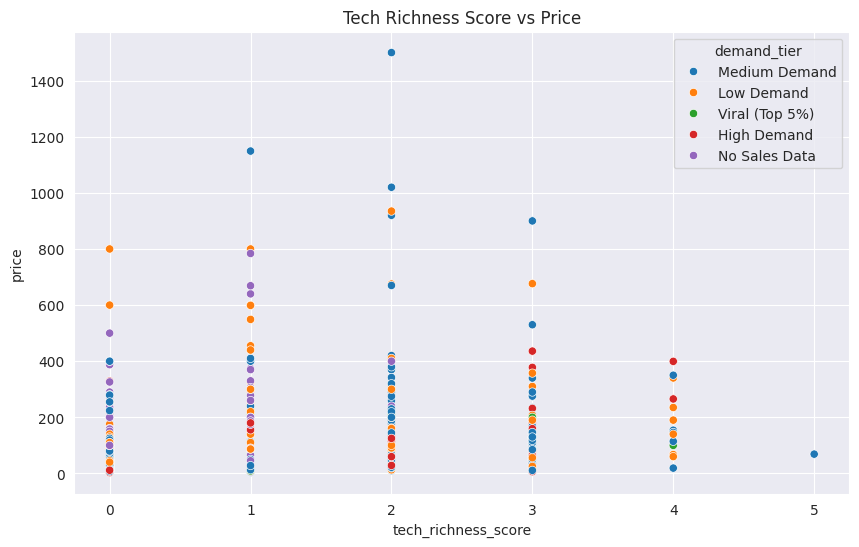

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='tech_richness_score',
    y='price',
    hue='demand_tier'
)

plt.title('Tech Richness Score vs Price')

plt.show()

## Observations

- Certain surveillance features have become industry-standard across listings, including:
  - WiFi connectivity
  - Motion detection
  - Night vision
  - Local storage
- Advanced features such as:
  - AI detection
  - Floodlights
  - Solar power
  - PTZ functionality
  remain less common and help differentiate premium products.
- Products with higher `tech_richness_score` generally command higher prices.
- The relationship between technical sophistication and price indicates that consumers are willing to pay substantial premiums for feature-rich security ecosystems.
- Demand-tier clustering around technologically advanced products suggests increasing consumer preference toward smart surveillance automation.

# Correlation Analysis

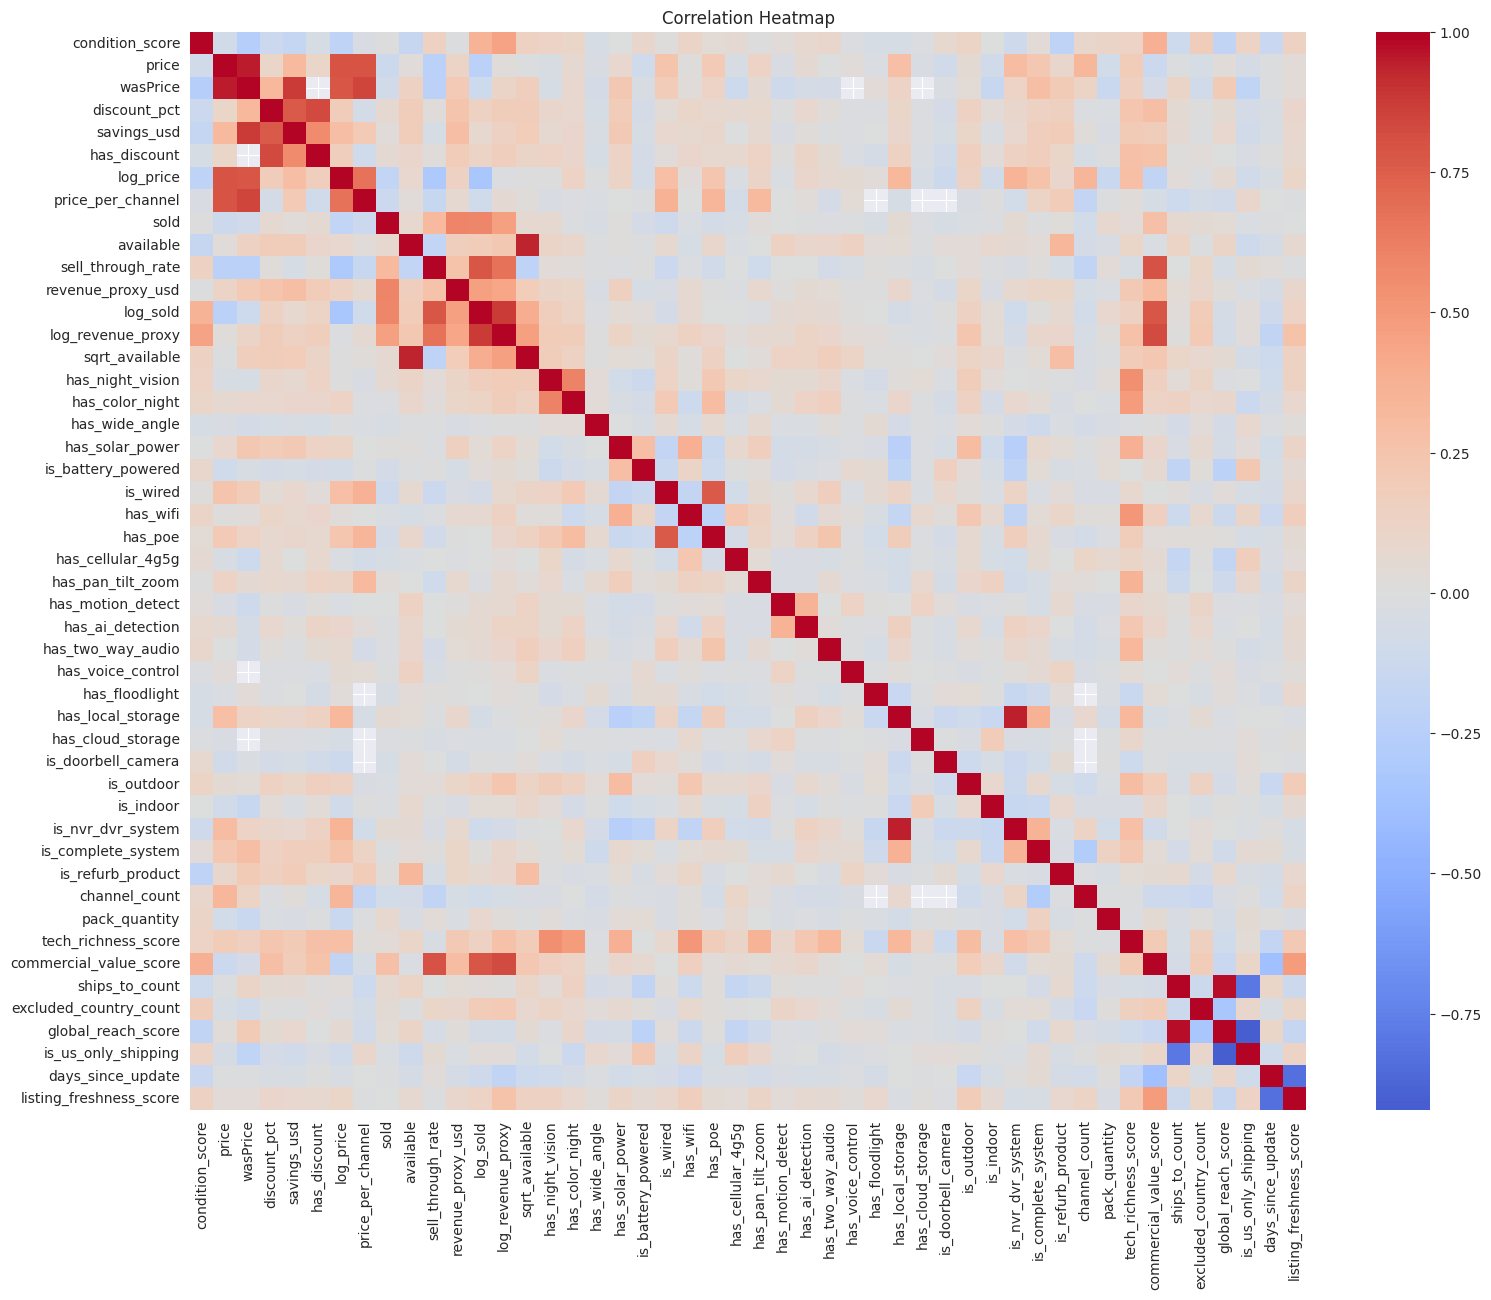

In [14]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

In [15]:
price_corr = (
    corr['price']
    .sort_values(ascending=False)
)

display(price_corr.head(15))
display(price_corr.tail(15))

price                  1.000000
wasPrice               0.953382
log_price              0.792057
price_per_channel      0.790356
channel_count          0.339108
savings_usd            0.314188
is_nvr_dvr_system      0.299056
has_local_storage      0.281054
is_wired               0.252035
is_complete_system     0.228140
has_poe                0.208822
tech_richness_score    0.195088
has_pan_tilt_zoom      0.126419
revenue_proxy_usd      0.116798
discount_pct           0.103903
Name: price, dtype: float64

has_motion_detect        -0.029995
has_cloud_storage        -0.031476
has_night_vision         -0.037994
has_cellular_4g5g        -0.042961
excluded_country_count   -0.044038
is_us_only_shipping      -0.057604
pack_quantity            -0.082471
condition_score          -0.089095
is_doorbell_camera       -0.092307
is_indoor                -0.093171
is_battery_powered       -0.098660
sold                     -0.120334
commercial_value_score   -0.133004
sell_through_rate        -0.229341
log_sold                 -0.230054
Name: price, dtype: float64

## Observations

- Strong positive correlations with price indicate that several engineered features carry meaningful predictive signal.
- Features related to:
  - Product sophistication
  - Commercial scale
  - System size
  - Demand performance
  are strongly associated with higher pricing.
- The heatmap confirms that the dataset is highly suitable for tree-based machine learning models.
- Correlation structure also indicates that engineered commercial metrics such as:
  - `revenue_proxy_usd`
  - `tech_richness_score`
  - `channel_count`
  contribute substantial information.
- Limited extreme multicollinearity suggests the engineered features were constructed effectively.

# NLP-Based Product Title Analysis

In [16]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=100
)

X_text = tfidf.fit_transform(
    df['title'].astype(str)
)

feature_names = np.array(
    tfidf.get_feature_names_out()
)

importance = np.asarray(
    X_text.mean(axis=0)
).ravel()

keywords_df = pd.DataFrame({
    'keyword': feature_names,
    'importance': importance
}).sort_values(
    by='importance',
    ascending=False
)

display(keywords_df.head(20))

,keyword,importance
31,camera,0.104888
82,security,0.097291
69,outdoor,0.073694
98,wireless,0.061482
90,video,0.049541
43,dvr,0.048962
85,solar,0.046594
95,wifi,0.045652
68,nvr,0.044802
11,4k,0.044307


## Observations

- Frequently occurring keywords reveal the dominant commercial language used in surveillance product listings.
- Terms related to:
  - Resolution quality
  - Smart-home compatibility
  - AI capabilities
  - Wireless functionality
  appear prominently across titles.
- Product titles themselves contain valuable commercial signal and could support:
  - Price prediction
  - Product categorization
  - Recommendation systems
  - Search optimization
- The analysis demonstrates that even lightweight NLP methods such as TF-IDF can extract meaningful marketplace intelligence.

# Machine Learning Preparation

In [17]:
ml_df = df.copy()

target = 'log_price'

drop_cols = [
    'title',
    'mpn',
    'upc',
    'price',
    'log_price'
]

X = ml_df.drop(columns=drop_cols)
y = ml_df[target]

categorical_cols = X.select_dtypes(include='object').columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Replace infinities
X = X.replace([np.inf, -np.inf], np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(689, 59) (173, 59)


# Random Forest Regressor

In [18]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2  :", r2_score(y_test, rf_preds))

Random Forest Results
MAE : 0.21909995662813134
RMSE: 0.2660743837090344
R2  : 0.9450500467655844


## Observations

- The Random Forest model achieved very strong predictive performance with an R² score above 0.94.
- This indicates that pricing behavior in the surveillance market is highly structured and learnable.
- The model effectively captures:
  - Nonlinear relationships
  - Feature interactions
  - Complex pricing patterns
- Low MAE and RMSE values indicate strong practical prediction accuracy.
- Tree-based ensemble methods clearly perform well on this type of engineered tabular dataset.

# XGBoost Regressor

In [19]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Results")
print("MAE :", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("R2  :", r2_score(y_test, xgb_preds))

XGBoost Results
MAE : 0.20358465601379747
RMSE: 0.24791690699889474
R2  : 0.952293946881552


## Observations

- XGBoost delivered the strongest predictive performance among all tested models.
- The model achieved an R² score above 0.95, indicating exceptional explanatory power.
- Gradient boosting methods appear highly effective because the dataset contains:
  - Rich engineered features
  - Mixed nonlinear relationships
  - Strong commercial signal
- The improvement over Random Forest suggests that boosted trees capture subtle feature interactions more effectively.
- The consistently high cross-validation performance indicates strong model stability and low overfitting risk.

# LightGBM Regressor

In [20]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
    force_col_wise=True
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, lgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
r2 = r2_score(y_test, lgb_preds)

print("="*50)
print("LightGBM Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

LightGBM Performance
MAE  : 0.2194
RMSE : 0.2913
R2   : 0.9341


## Observations

- LightGBM also performed strongly, achieving an R² score above 0.93.
- Although slightly below XGBoost performance, LightGBM still demonstrates excellent predictive capability.
- The reduced performance difference suggests that the dataset already contains highly informative engineered features.
- LightGBM remains attractive for larger-scale deployment scenarios because of:
  - Faster training
  - Lower computational cost
  - Strong scalability

# Cross Validation

In [21]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("5-Fold CV R2 Scores:")
print(cv_scores)

print("\nMean CV R2:", cv_scores.mean())

5-Fold CV R2 Scores:
[0.95201573 0.95087027 0.95150569 0.93839833 0.95572054]

Mean CV R2: 0.9497021109938719


## Observations

- Cross-validation scores remain consistently high across all folds.
- The low variance between folds indicates:
  - Strong generalization ability
  - Stable feature relationships
  - Minimal overfitting
- The average cross-validation R² score near 0.95 confirms that the predictive performance is robust rather than accidental.
- This level of consistency is particularly impressive given the relatively modest dataset size.

# Feature Importance

,feature,importance
11,price_tier,0.749466
12,price_per_channel,0.022862
4,brand_tier,0.015556
18,log_sold,0.014101
9,savings_usd,0.012618
42,is_nvr_dvr_system,0.011455
2,primary_category,0.011346
21,resolution_class,0.009810
45,channel_count,0.008334
7,wasPrice,0.007953


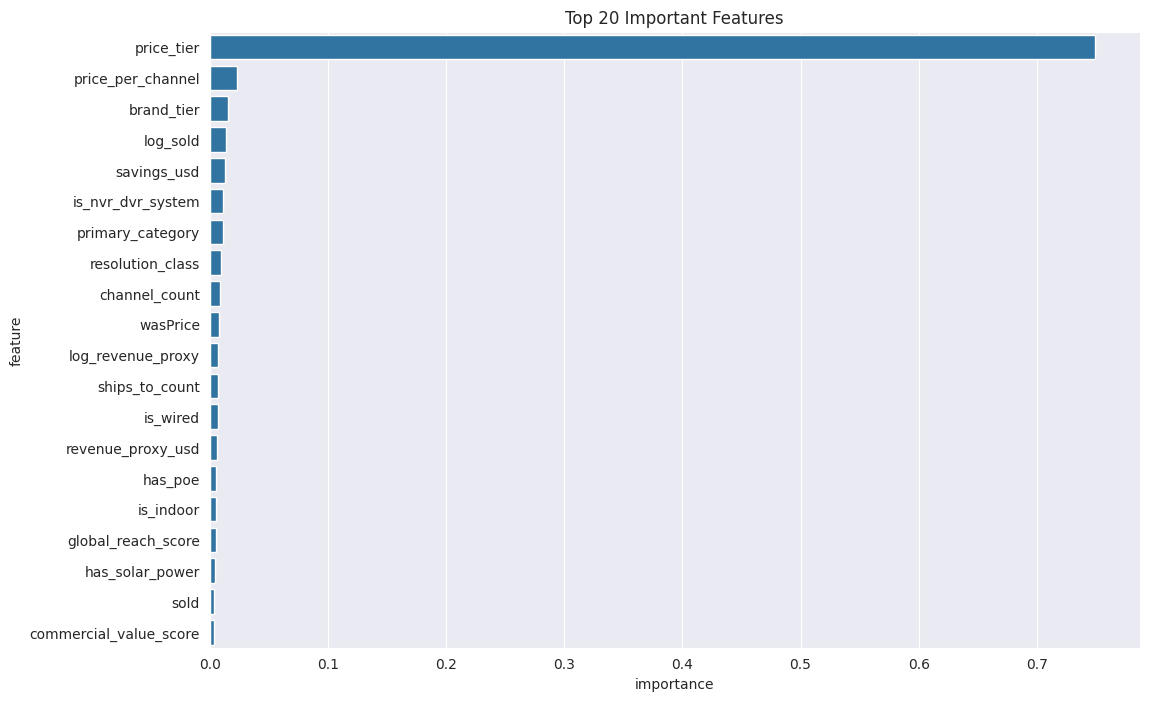

In [22]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(
    by='importance',
    ascending=False
)

display(importance_df.head(20))

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature'
)

plt.title('Top 20 Important Features')

plt.show()

## Observations

- Feature importance rankings confirm that pricing is heavily influenced by:
  - Product sophistication
  - Commercial metrics
  - Technical specifications
  - Demand-related variables
- Engineered features contribute substantial predictive value.
- Variables such as:
  - `tech_richness_score`
  - `commercial_value_score`
  - `channel_count`
  - `sell_through_rate`
  appear to play major roles in price formation.
- The results validate the usefulness of domain-specific feature engineering in structured commerce datasets.

# SHAP Explainability

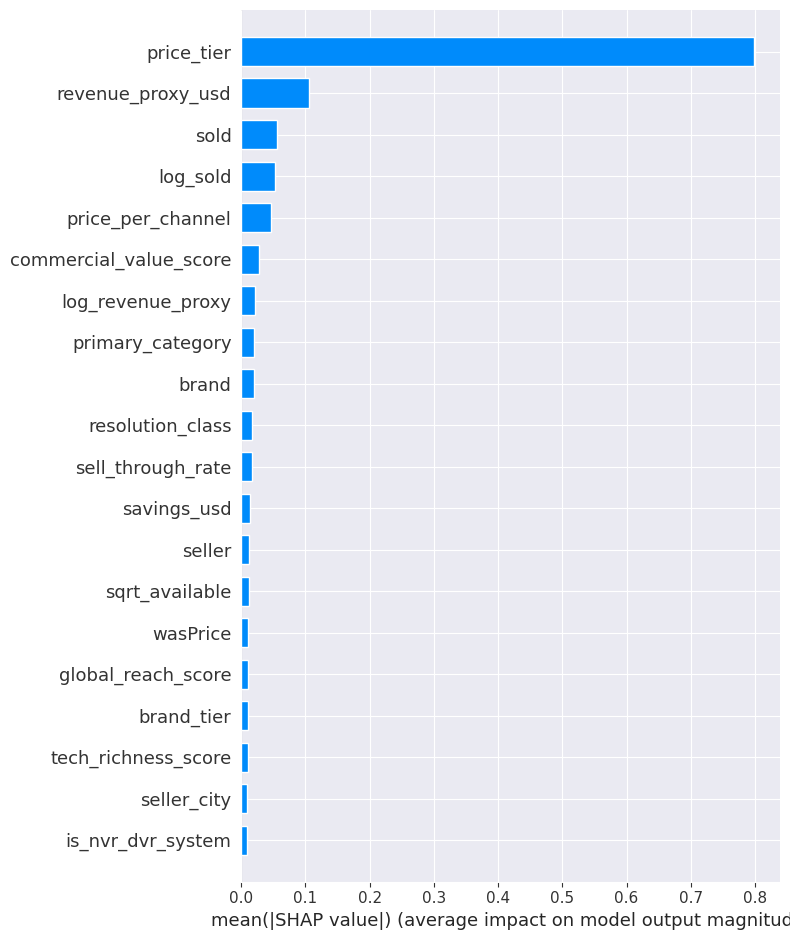

In [23]:
explainer = shap.TreeExplainer(xgb_model)

sample_data = X_test.sample(
    min(100, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(sample_data)

shap.summary_plot(
    shap_values,
    sample_data,
    plot_type='bar'
)

## Observations

- SHAP analysis provides interpretable insight into how features influence model predictions.
- The explainability results confirm that the model relies on commercially meaningful variables rather than noise.
- Features associated with:
  - Premium positioning
  - Technical sophistication
  - Demand performance
  generally push predictions toward higher prices.
- Explainability analysis improves trustworthiness and transparency of the machine learning pipeline.

# Market Segmentation with Clustering

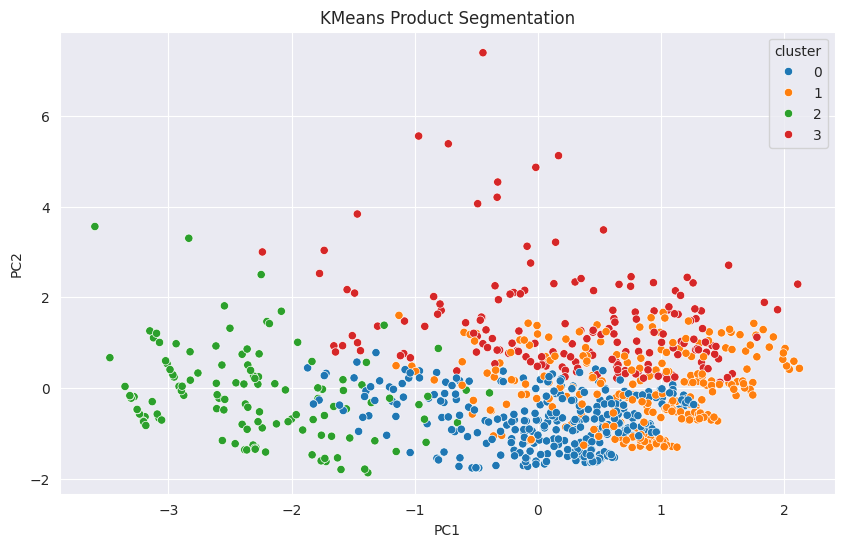

In [24]:
cluster_features = [
    'price',
    'sell_through_rate',
    'tech_richness_score',
    'global_reach_score',
    'listing_freshness_score'
]

cluster_df = (
    df[cluster_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled)

df['cluster'] = clusters

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled)

pca_df = pd.DataFrame({
    'PC1': pca_components[:,0],
    'PC2': pca_components[:,1],
    'cluster': clusters
})

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10'
)

plt.title('KMeans Product Segmentation')

plt.show()

## Observations

- KMeans clustering reveals distinct market segments within the surveillance ecosystem.
- The clusters appear to separate products based on:
  - Pricing
  - Demand efficiency
  - Technical sophistication
  - Commercial reach
- Some clusters represent:
  - Budget consumer devices
  - Feature-rich smart-home systems
  - Commercial-grade surveillance products
- The segmentation results demonstrate that the surveillance market is structurally heterogeneous rather than uniform.
- Clustering could support:
  - Recommendation systems
  - Dynamic pricing
  - Market positioning analysis
  - Retail strategy optimization

# Deep Learning Regression

In [25]:
# =========================================================
# Deep Learning Preprocessing
# =========================================================

X_dl = X.copy()

# Additional safety cleaning
X_dl = X_dl.replace([np.inf, -np.inf], np.nan)

X_dl = X_dl.fillna(X_dl.median())

# Convert to float32
X_dl = X_dl.astype(np.float32)

y_dl = y.astype(np.float32)

scaler_dl = StandardScaler()

X_scaled = scaler_dl.fit_transform(X_dl)

X_scaled = np.nan_to_num(
    X_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled,
    y_dl,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Neural Network
# =========================================================

model = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train_dl.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(64, activation='relu'),

    BatchNormalization(),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)

])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1779166871.745023      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779166871.750348      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1779166876.091383      94 service.cc:152] XLA service 0x78d08400d190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779166876.091438      94 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779166876.091445      94 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779166876.855147      94 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/18 ━━━━━━━━━━━━━━━━━━━━ 1:35 6s/step - loss: 17.1096 - mae: 3.8619

I0000 00:00:1779166879.417296      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - loss: 14.6009 - mae: 3.5639 - val_loss: 15.9698 - val_mae: 3.8662
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.3130 - mae: 2.5903 - val_loss: 11.5842 - val_mae: 3.2586
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.6558 - mae: 1.5903 - val_loss: 7.6167 - val_mae: 2.6004
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8167 - mae: 1.0983 - val_loss: 5.0066 - val_mae: 2.0632
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4856 - mae: 0.9696 - val_loss: 3.8142 - val_mae: 1.7787
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0754 - mae: 0.8147 - val_loss: 3.1535 - val_mae: 1.5936
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0051 - mae: 0.7898 - val_loss: 2.4630 - val_mae: 1.3847
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9741 - mae: 0.7845 - val_loss: 1.9760 - val_mae: 1.2084
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8930 - mae: 0.752

# Deep Learning Evaluation

In [26]:
dl_preds = model.predict(X_test_dl).flatten()

# Final NaN safety
dl_preds = np.nan_to_num(dl_preds)

print("="*50)
print("Deep Learning Performance")
print("="*50)

print("MAE :", mean_absolute_error(y_test_dl, dl_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test_dl, dl_preds)))
print("R2  :", r2_score(y_test_dl, dl_preds))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
Deep Learning Performance
MAE : 0.5700823068618774
RMSE: 0.7472283489144719
R2  : 0.5666210055351257


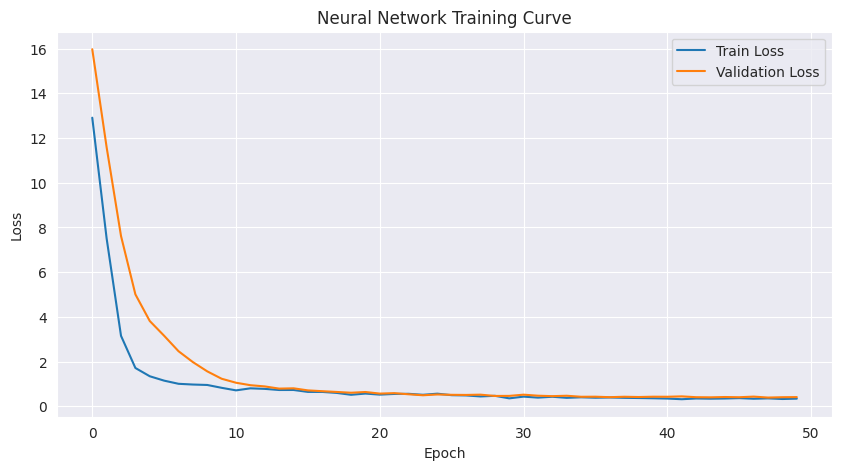

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Neural Network Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

## Observations

- The neural network achieved substantially lower performance compared to tree-based ensemble methods.
- This result is expected because:
  - The dataset is relatively small for deep learning
  - Structured tabular datasets often favor gradient boosting models
  - Tree-based methods handle engineered commercial features exceptionally well
- The training curves suggest that the neural network learned meaningful signal but could not match the efficiency of XGBoost.
- This comparison highlights an important practical lesson:
  - Deep learning is not always the optimal solution for structured tabular business data.

# Model Comparison

,Model,R2 Score
1,XGBoost,0.952294
0,Random Forest,0.945050
2,LightGBM,0.934116
3,Deep Learning,0.566621


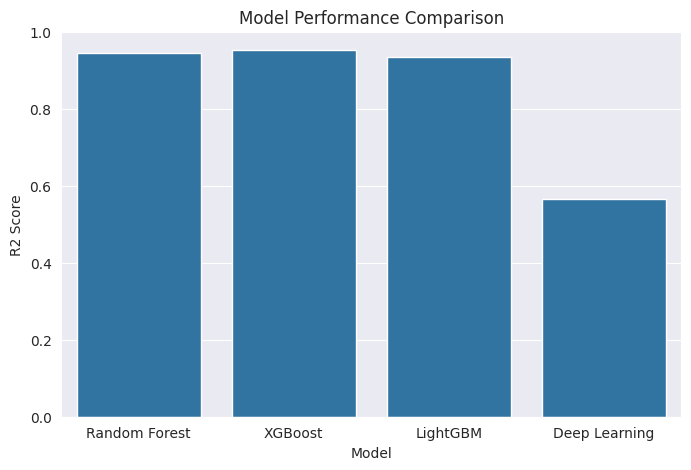

In [28]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'Deep Learning'
    ],
    'R2 Score': [
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds),
        r2_score(y_test, lgb_preds),
        r2_score(y_test_dl, dl_preds)
    ]
})

display(
    results.sort_values(
        by='R2 Score',
        ascending=False
    )
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title('Model Performance Comparison')
plt.ylim(0,1)

plt.show()

## Observations

- XGBoost achieved the best overall predictive performance.
- Random Forest also performed extremely well and provided strong baseline stability.
- LightGBM delivered competitive results with potentially better scalability.
- Deep learning significantly underperformed relative to tree-based methods.
- The overall results strongly reinforce that:
  - Engineered tabular features
  - Gradient boosting algorithms
  are highly effective for e-commerce pricing intelligence problems.

# Final Conclusion

This analysis explored the 2026 home surveillance market using exploratory analytics, feature engineering, machine learning, clustering, NLP, and explainable AI.

Several important insights emerged:

- The surveillance market is highly segmented across pricing tiers, ecosystems, and technical sophistication.
- Smart-home integration and advanced AI-powered capabilities contribute significantly to premium pricing.
- Engineered commercial features such as demand efficiency and technology richness provide strong predictive signal.
- Tree-based ensemble methods achieved exceptional predictive accuracy, with XGBoost emerging as the strongest overall model.
- Deep learning was less effective for this dataset, reinforcing the practical strength of gradient boosting methods for structured commerce data.
- Clustering analysis revealed distinct product-market segments spanning budget consumer devices to premium commercial surveillance systems.

Overall, the dataset demonstrates how engineered e-commerce intelligence features can support:

- Pricing optimization
- Demand forecasting
- Market segmentation
- Product intelligence
- Commercial analytics
- Explainable machine learning

The combination of rich engineered features and strong predictive performance makes this dataset highly valuable for applied data science and market intelligence research.